In [3]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format = "retina"
import shapely # map-rendering library
import numpy as np
import fiona # enging for reading more robust data files

In [4]:
counties = gpd.read_file("../Parks/Counties.geojson", engine="fiona")
# counties.head()
parks = gpd.read_file("../Parks/Parks_(2024).geojson")
# parks.head()
counties_projected = counties.to_crs("EPSG:3083")
parks_projected = parks.to_crs("EPSG:3083")
# counties_projected.head()

In [5]:
#dallas_county = counties_projected.loc[counties_projected["COUNTY"] == "Dallas"]
dallas_geometry = counties_projected.loc[counties_projected["COUNTY"] == "Dallas", "geometry"].iloc[0]
parks_projected["intersects"] = parks_projected.intersects(dallas_geometry) 

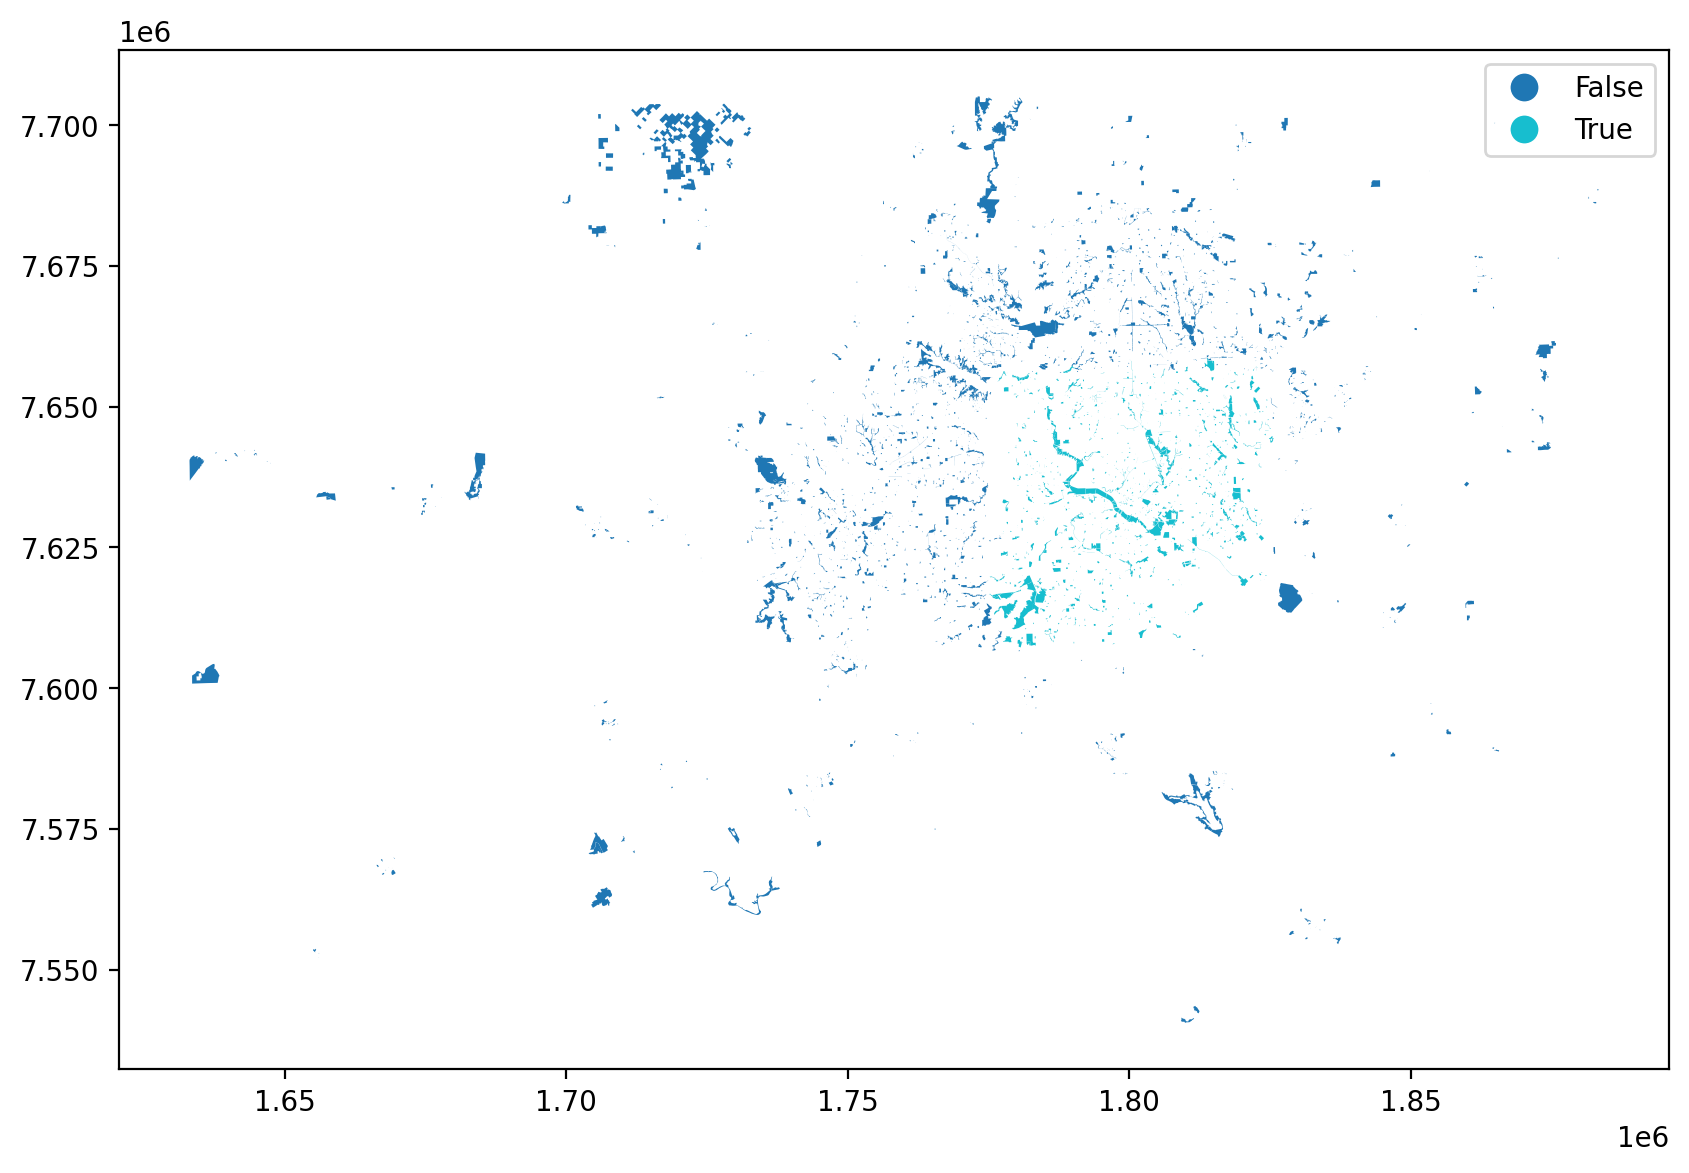

In [6]:
parks_projected.plot(column="intersects", categorical=True, legend=True, figsize=(10, 10));

<Axes: >

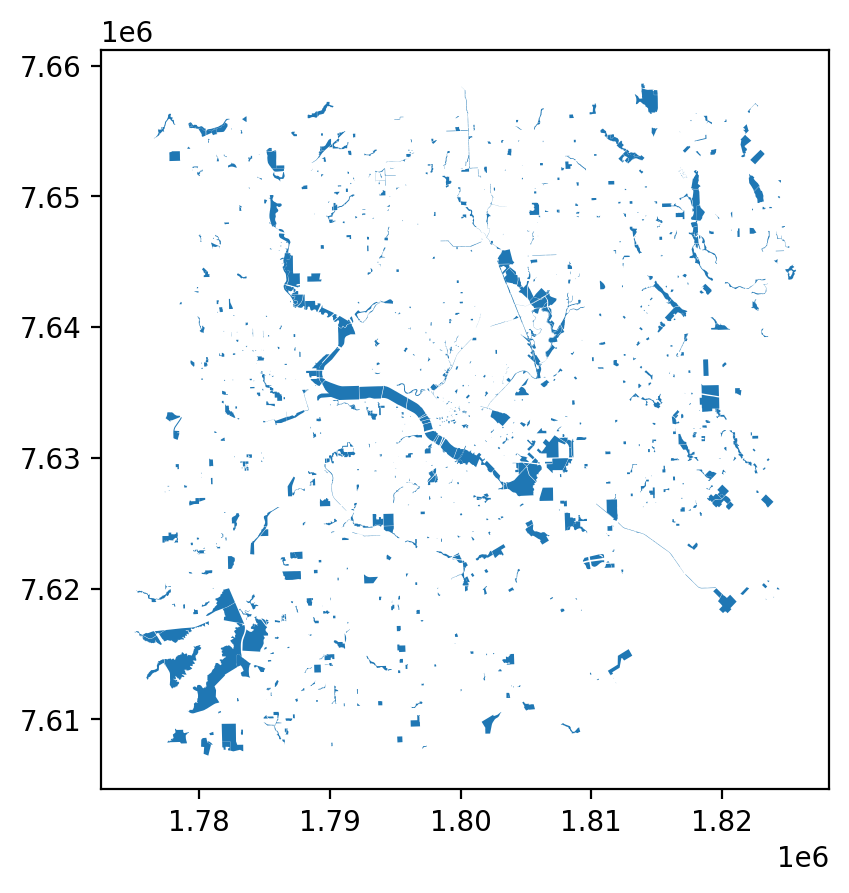

In [11]:
dallas_county_parks = parks_projected.loc[parks_projected["intersects"] == True]
dallas_county_parks.plot()

In [29]:
dallas_county_parks["centroid"] = dallas_county_parks.centroid
dallas_county_parks.head()

/users/sankarana/.local/lib/python3.11/site-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,OBJECTID,NAME,OWNER,NOTES,CITY,FEATTYPE,STATUS,SOURCE,SOURCE_YEAR,ShapeSTLength,ShapeSTArea,geometry,intersects,centroid
11,12,Twin Star Park,None,E,Rowlett,Local Park,Existing,City of Rowlett,2023,1759.912421,181896.035984,"POLYGON ((1824286.705 7649930.7, 1824341.335 7...",True,POINT (1824356.323 7649942.011)
12,13,Columbia Park,None,F,Rowlett,Local Park,Proposed,City of Rowlett,2023,1200.661102,84838.762961,"POLYGON ((1822292.592 7648935.241, 1822360.091...",True,POINT (1822328.099 7648992.095)
13,14,Paddle Point/N Lakeside,None,E,Rowlett,Local Park,Existing,City of Rowlett,2023,8033.013397,735614.787512,"MULTIPOLYGON (((1823582.29 7647358.52, 1823567...",True,POINT (1823548.15 7646873.734)
14,15,Kenwood Heights,None,E,Rowlett,Local Park,Existing,City of Rowlett,2023,3385.494851,149958.984225,"POLYGON ((1819471.686 7648638.36, 1819634.792 ...",True,POINT (1819691.015 7648403.018)
15,16,Veterans Memorial Park,None,E,Rowlett,Local Park,Existing,City of Rowlett,2023,882.415201,28145.654443,"POLYGON ((1820720.487 7647472.798, 1820720.737...",True,POINT (1820710.256 7647416.783)


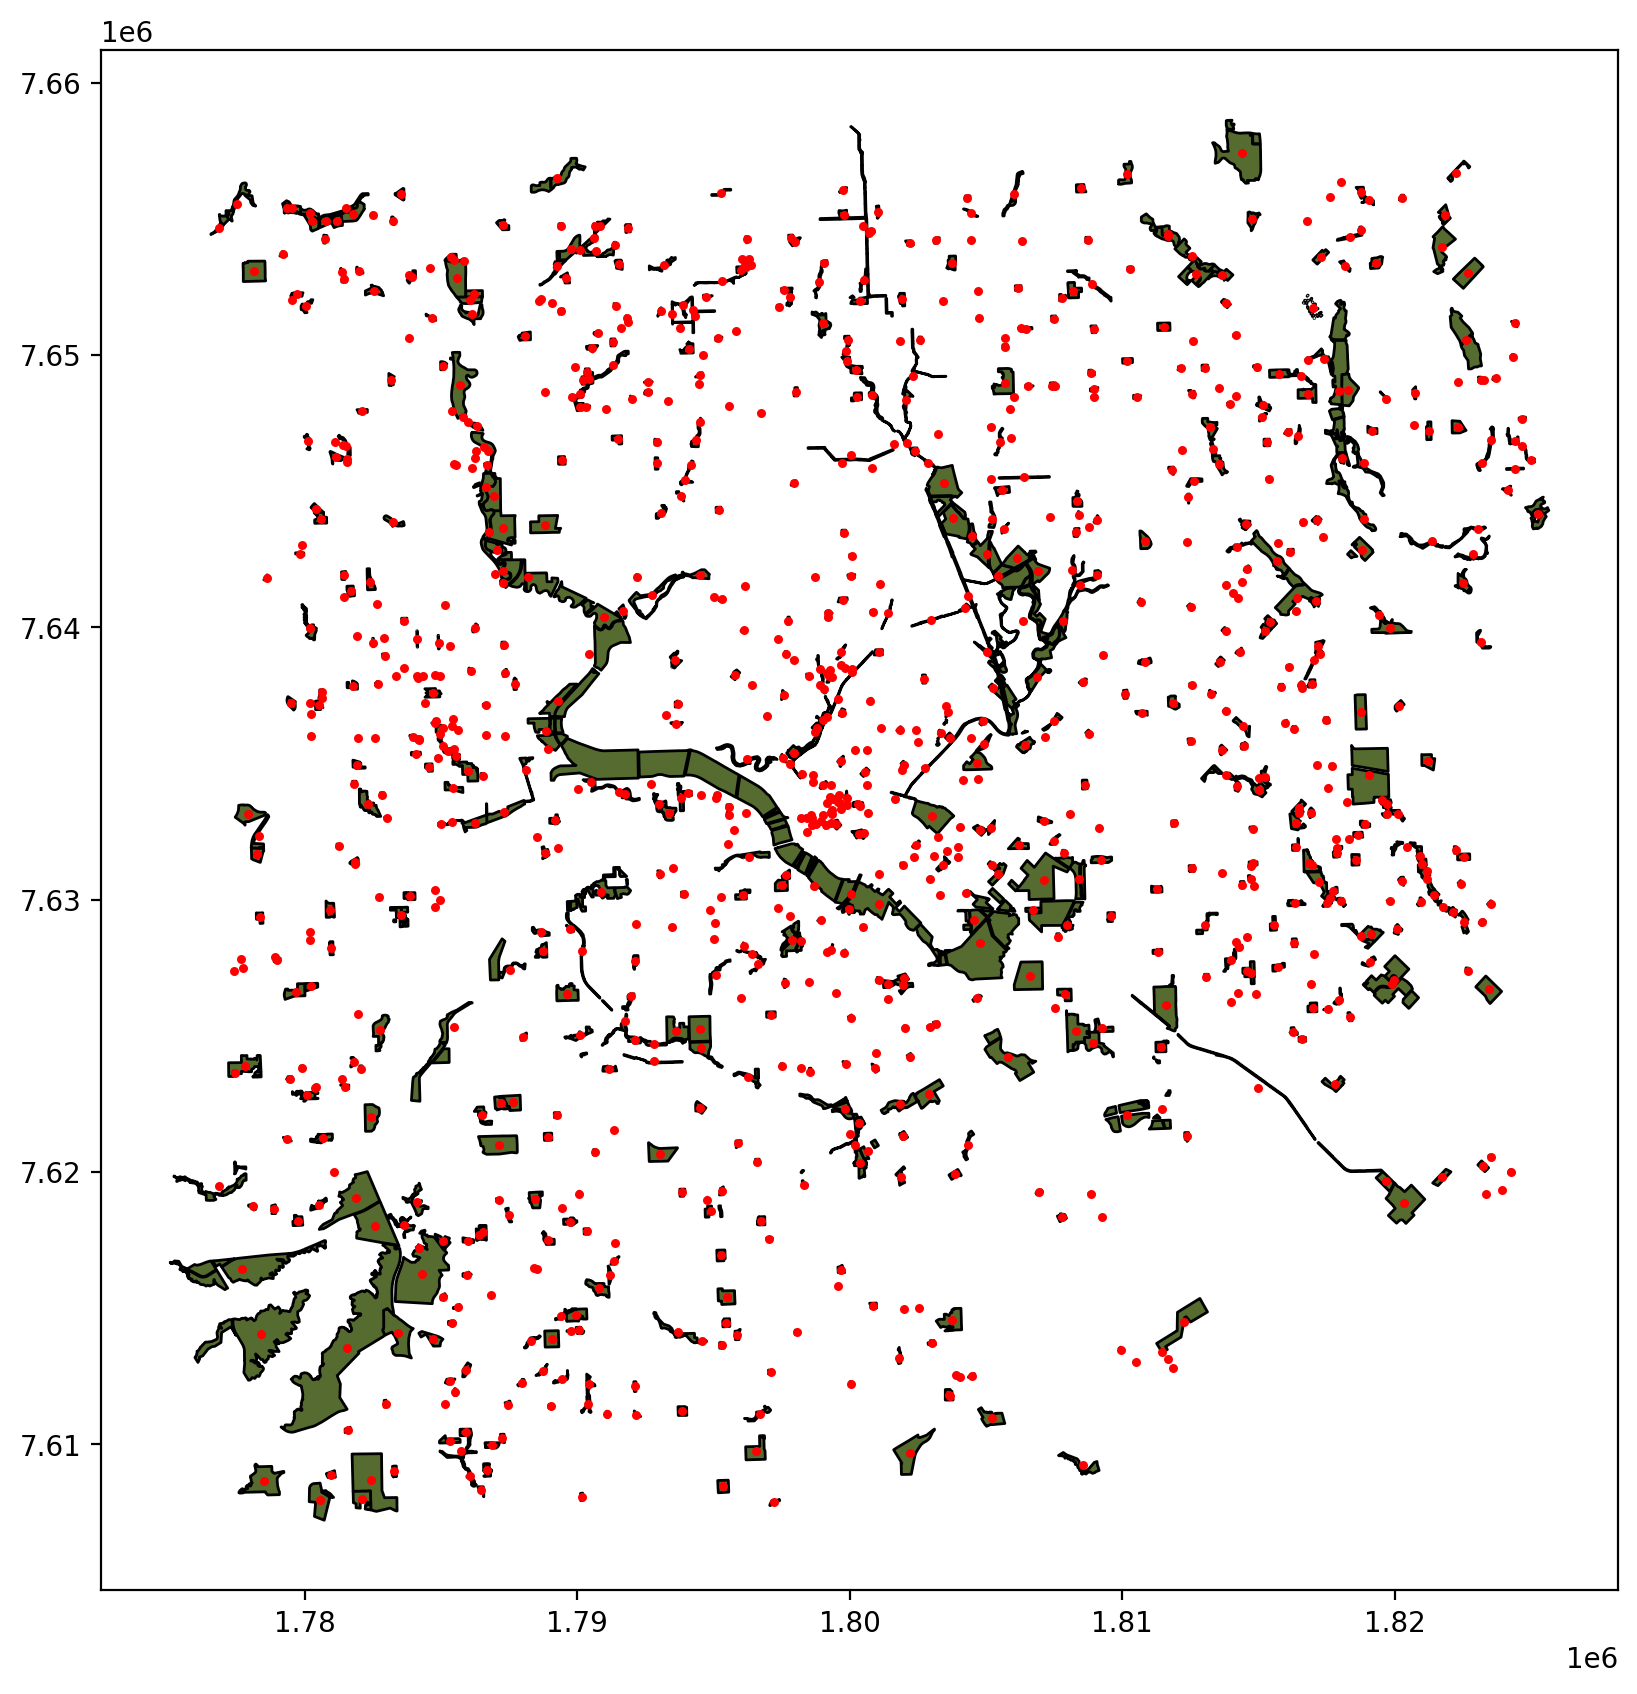

In [26]:
ax = dallas_county_parks.plot(color="darkolivegreen", edgecolor="black", figsize=(10, 10))
dallas_county_parks.set_geometry("centroid").plot(ax=ax, color="red", markersize=5);

In [40]:
print(dallas_county_parks["STATUS"].value_counts())
dallas_county_existing_parks = dallas_county_parks[dallas_county_parks["STATUS"] == "Existing"]
dallas_county_existing_parks["STATUS"].value_counts()

STATUS
Existing    1007
Proposed      16
Name: count, dtype: int64


STATUS
Existing    1007
Name: count, dtype: int64

In [52]:
dallas_county_existing_parks.shape
dallas_county_existing_parks.columns

Index(['OBJECTID', 'NAME', 'OWNER', 'NOTES', 'CITY', 'FEATTYPE', 'STATUS',
       'SOURCE', 'SOURCE_YEAR', 'ShapeSTLength', 'ShapeSTArea', 'geometry',
       'intersects', 'centroid'],
      dtype='object')

In [55]:
# shp
centroids = dallas_county_existing_parks[["NAME", "CITY", "centroid"]]
centroids.to_file('centroids.shp')